In [7]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, \
    TimeSeriesResampler
import seaborn as sns
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import silhouette_score

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.cluster

import os
from yellowbrick.cluster import SilhouetteVisualizer

import math
import scipy

from sklearn.metrics import adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from tslearn.metrics import soft_dtw

In [11]:
df = pd.read_excel('chapter04_data.xlsx', sheet_name='embedding')

In [13]:
df

,Unnamed: 0,Unnamed: 1,No-embed,PCA,DAE+,DAE+ Agglom-knn,"DAE+-Agglom+ [DTW, centroid]",Improvement over PCA with DAE-kmeans,Improvement over PCA with DAE-Agglom+,Unnamed: 9
0,BR,3,0.5661,0.7625,0.7685,0.8016,0.7588,1.007869,0.995148,-0.012721
1,BR,4,0.5074,0.6950,0.7321,0.7100,0.7171,1.053381,1.031799,-0.021583
2,BR,5,0.4400,0.6041,0.7031,0.7148,0.6991,1.163880,1.157259,-0.006621
3,BR,6,0.3886,0.5890,0.7224,0.6836,0.6413,1.226486,1.088795,-0.137691
4,BR,7,0.3610,0.5566,0.6537,0.6258,0.6711,1.174452,1.205713,0.031261
5,BR,8,0.3285,0.5487,0.6007,0.5886,0.6365,1.094769,1.160015,0.065245
6,BR,9,0.2790,0.5370,0.5601,0.5697,0.6098,1.043017,1.135568,0.092551
7,BR,10,0.2676,0.5243,0.5487,0.5343,0.5669,1.046538,1.081251,0.034713
8,ECV,3,0.6214,0.6228,0.9424,0.9198,0.9096,1.513166,1.460501,-0.052665
9,ECV,4,0.6180,0.6210,0.8998,0.8902,0.8927,1.448953,1.437520,-0.011433


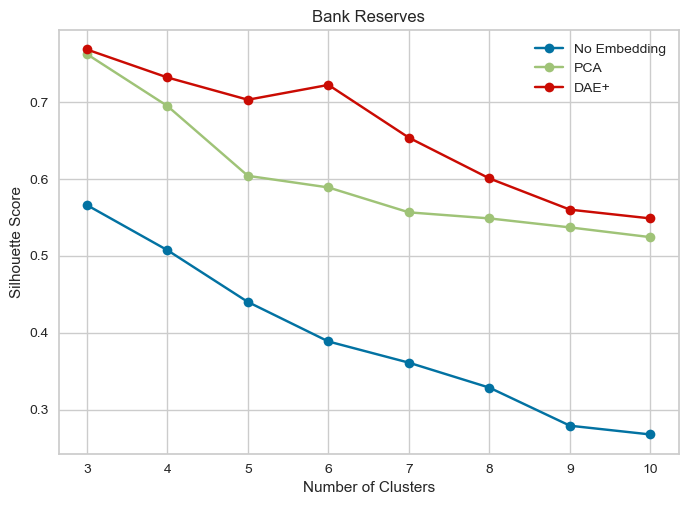

In [33]:
df_subset = df[df['Unnamed: 0'] == 'BR']
plt.plot(df_subset['Unnamed: 1'], df_subset['No-embed'], label = "No Embedding", linestyle = 'solid', marker = 'o')
plt.plot(df_subset['Unnamed: 1'], df_subset['PCA'], label = "PCA", linestyle = 'solid', marker = 'o')
plt.plot(df_subset['Unnamed: 1'], df_subset['DAE+'], label = "DAE+", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Bank Reserves")
plt.legend() 

plt.savefig('br_size_of_k_silhouette.png')

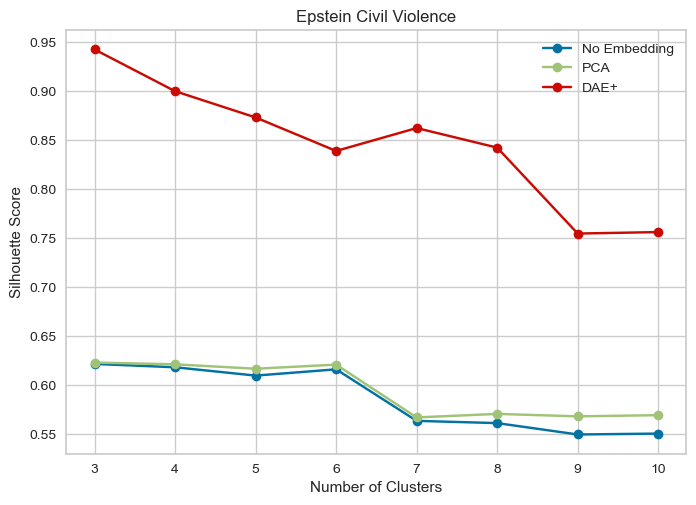

In [37]:
df_subset = df[df['Unnamed: 0'] == 'ECV']
plt.plot(df_subset['Unnamed: 1'], df_subset['No-embed'], label = "No Embedding", linestyle = 'solid', marker = 'o')
plt.plot(df_subset['Unnamed: 1'], df_subset['PCA'], label = "PCA", linestyle = 'solid', marker = 'o')
plt.plot(df_subset['Unnamed: 1'], df_subset['DAE+'], label = "DAE+", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Epstein Civil Violence")
plt.legend() 

plt.savefig('ecv_size_of_k_silhouette.png')

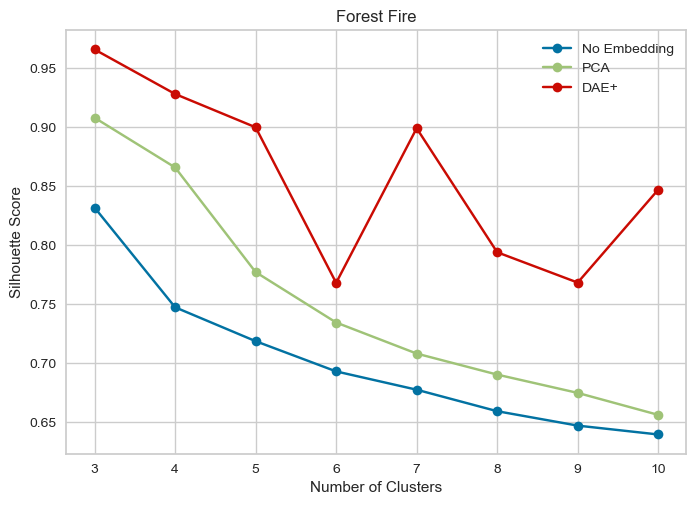

In [39]:
df_subset = df[df['Unnamed: 0'] == 'FF']
plt.plot(df_subset['Unnamed: 1'], df_subset['No-embed'], label = "No Embedding", linestyle = 'solid', marker = 'o')
plt.plot(df_subset['Unnamed: 1'], df_subset['PCA'], label = "PCA", linestyle = 'solid', marker = 'o')
plt.plot(df_subset['Unnamed: 1'], df_subset['DAE+'], label = "DAE+", linestyle = 'solid', marker = 'o')


plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Forest Fire")
plt.legend() 

plt.savefig('ff_size_of_k_silhouette.png')